In [26]:
import json
labels = ['business', 'entertainment',
          'politics', 'sport', 'tech']  # BBC categories
with open('model_artifacts/labels.json', 'w') as f:
    json.dump({'categories': labels}, f)

# EDA: BBC News Dataset (Sample)

Analyzing the sample CSV for text classification insights.

In [8]:
!uv pip install pandas numpy matplotlib seaborn scikit-learn jupyterlab datasets python-multipart

Using Python 3.12.3 environment at: /media/firdousbhat/PROJECTS/PRACTICE/AI/bbc_text_classifier/.venv
Audited 8 packages in 11ms


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import json
import numpy as np
from sklearn.model_selection import train_test_split

# Load data (adjust path if notebooks/ is not at root)
df = pd.read_csv('data/bbc_sample.csv')
print(f"Dataset shape: {df.shape}")

# Debug: Inspect
print("Original Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nAny missing values?")
print(df.isnull().sum())

# Auto-rename common column variants
text_col = None
cat_col = None
for col in df.columns:
    if any(word in col.lower() for word in ['text', 'content', 'article', 'body']):
        text_col = col
    if any(word in col.lower() for word in ['category', 'label', 'topic', 'class']):
        cat_col = col

if text_col and text_col != 'text':
    df = df.rename(columns={text_col: 'text'})
    print(f"Renamed '{text_col}' to 'text'")
else:
    print("Text column is already 'text' or not found.")
if cat_col and cat_col != 'category':
    df = df.rename(columns={cat_col: 'category'})
    print(f"Renamed '{cat_col}' to 'category'")
else:
    print("Category column is already 'category' or not found.")

# Drop rows with missing text/category if any
df = df.dropna(subset=['text', 'category'])
print(f"Cleaned shape: {df.shape}")

# Final check
print("\nFinal Columns:", df.columns.tolist())
print("\nSample categories:", df['category'].unique())

Dataset shape: (5, 2)
Original Columns: ['text', 'label']

First few rows:
                                                text     label
0  The stock market rallied after the earnings re...  business
1  Parliament debated the new law for several hours.  politics
2  New smartphone releases push innovation in pro...      tech
3  A new climate report calls for urgent action b...  politics
4  Startups raised fresh capital as investors ret...  business

Data types:
text     object
label    object
dtype: object

Any missing values?
text     0
label    0
dtype: int64
Text column is already 'text' or not found.
Renamed 'label' to 'category'
Cleaned shape: (5, 2)

Final Columns: ['text', 'category']

Sample categories: ['business' 'politics' 'tech']


## Dataset Overview

Categories: ['business' 'politics' 'tech']

Category distribution:
 category
business    2
politics    2
tech        1
Name: count, dtype: int64


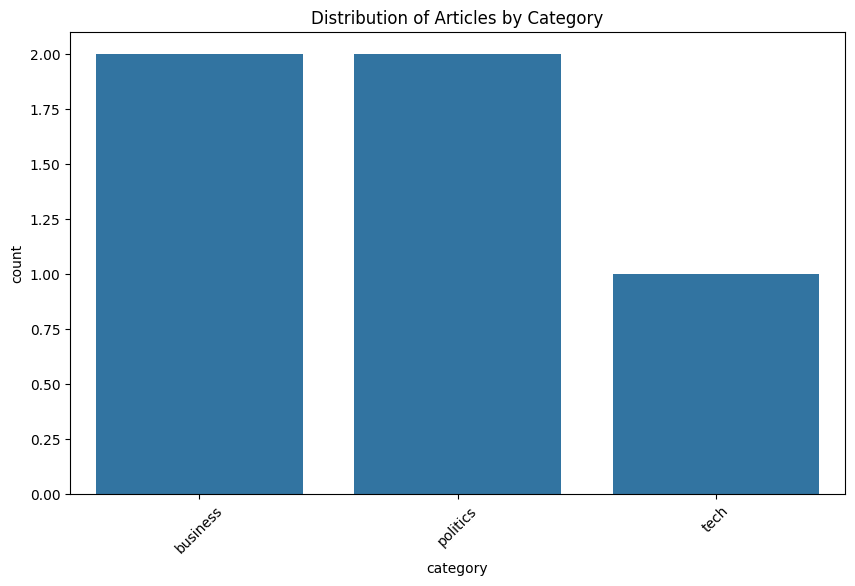

In [33]:
if 'category' not in df.columns or 'text' not in df.columns:
    print("ERROR: Still missing 'text' or 'category'—fix above!")
else:
    print("Categories:", df['category'].unique())
    print("\nCategory distribution:\n", df['category'].value_counts())

    # Plot distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='category',
                  order=df['category'].value_counts().index)
    plt.title('Distribution of Articles by Category')
    plt.xticks(rotation=45)
    plt.show()

## Text Length Stats

In [16]:
from datasets import Dataset
ds = Dataset.from_pandas(df)
print(ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 5
})



Text length stats:
 count     5.000000
mean     52.400000
std       2.701851
min      49.000000
25%      51.000000
50%      52.000000
75%      54.000000
max      56.000000
Name: text_length, dtype: float64


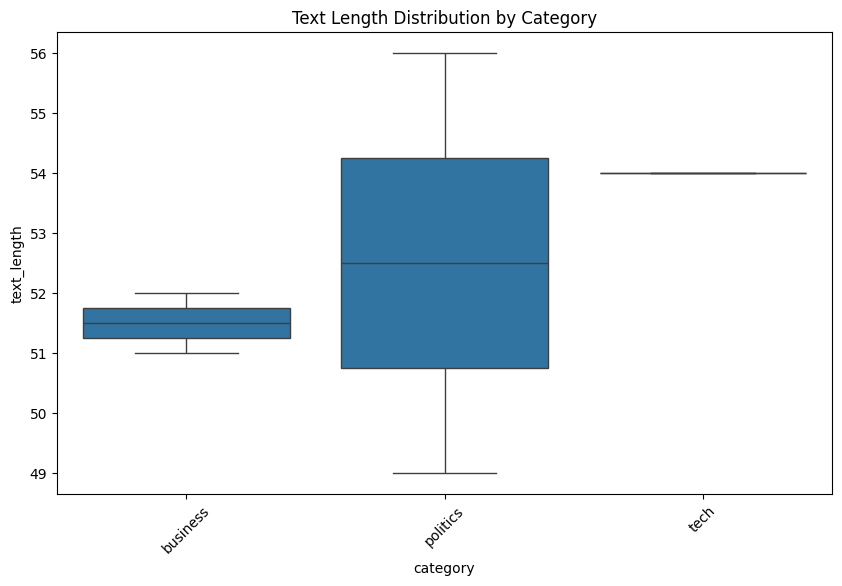

In [34]:
df['text_length'] = df['text'].apply(len)
print("\nText length stats:\n", df['text_length'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='text_length')
plt.title('Text Length Distribution by Category')
plt.xticks(rotation=45)
plt.show()

Class distribution:
label
business    2
politics    2
tech        1
Name: count, dtype: int64
count     5.000000
mean      8.000000
std       1.224745
min       7.000000
25%       7.000000
50%       8.000000
75%       8.000000
max      10.000000
Name: text_len, dtype: float64


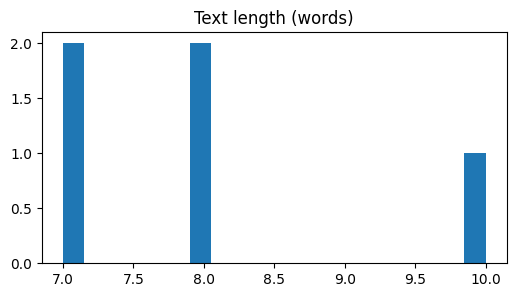

In [17]:
# EDA: class distribution & length
import matplotlib.pyplot as plt
print("Class distribution:")
print(df['label'].value_counts())

df['text_len'] = df['text'].astype(str).map(lambda s: len(s.split()))
print(df['text_len'].describe())

plt.figure(figsize=(6, 3))
plt.hist(df['text_len'], bins=20)
plt.title("Text length (words)")
plt.show()

## Text Preprocessing & Word Analysis

Average word count per category:
 category
business    7.5
politics    9.0
tech        7.0
Name: word_count, dtype: float64

Top 20 common words:
 [('the', 3), ('new', 3), ('report', 2), ('for', 2), ('stock', 1), ('market', 1), ('rallied', 1), ('after', 1), ('earnings', 1), ('parliament', 1)]


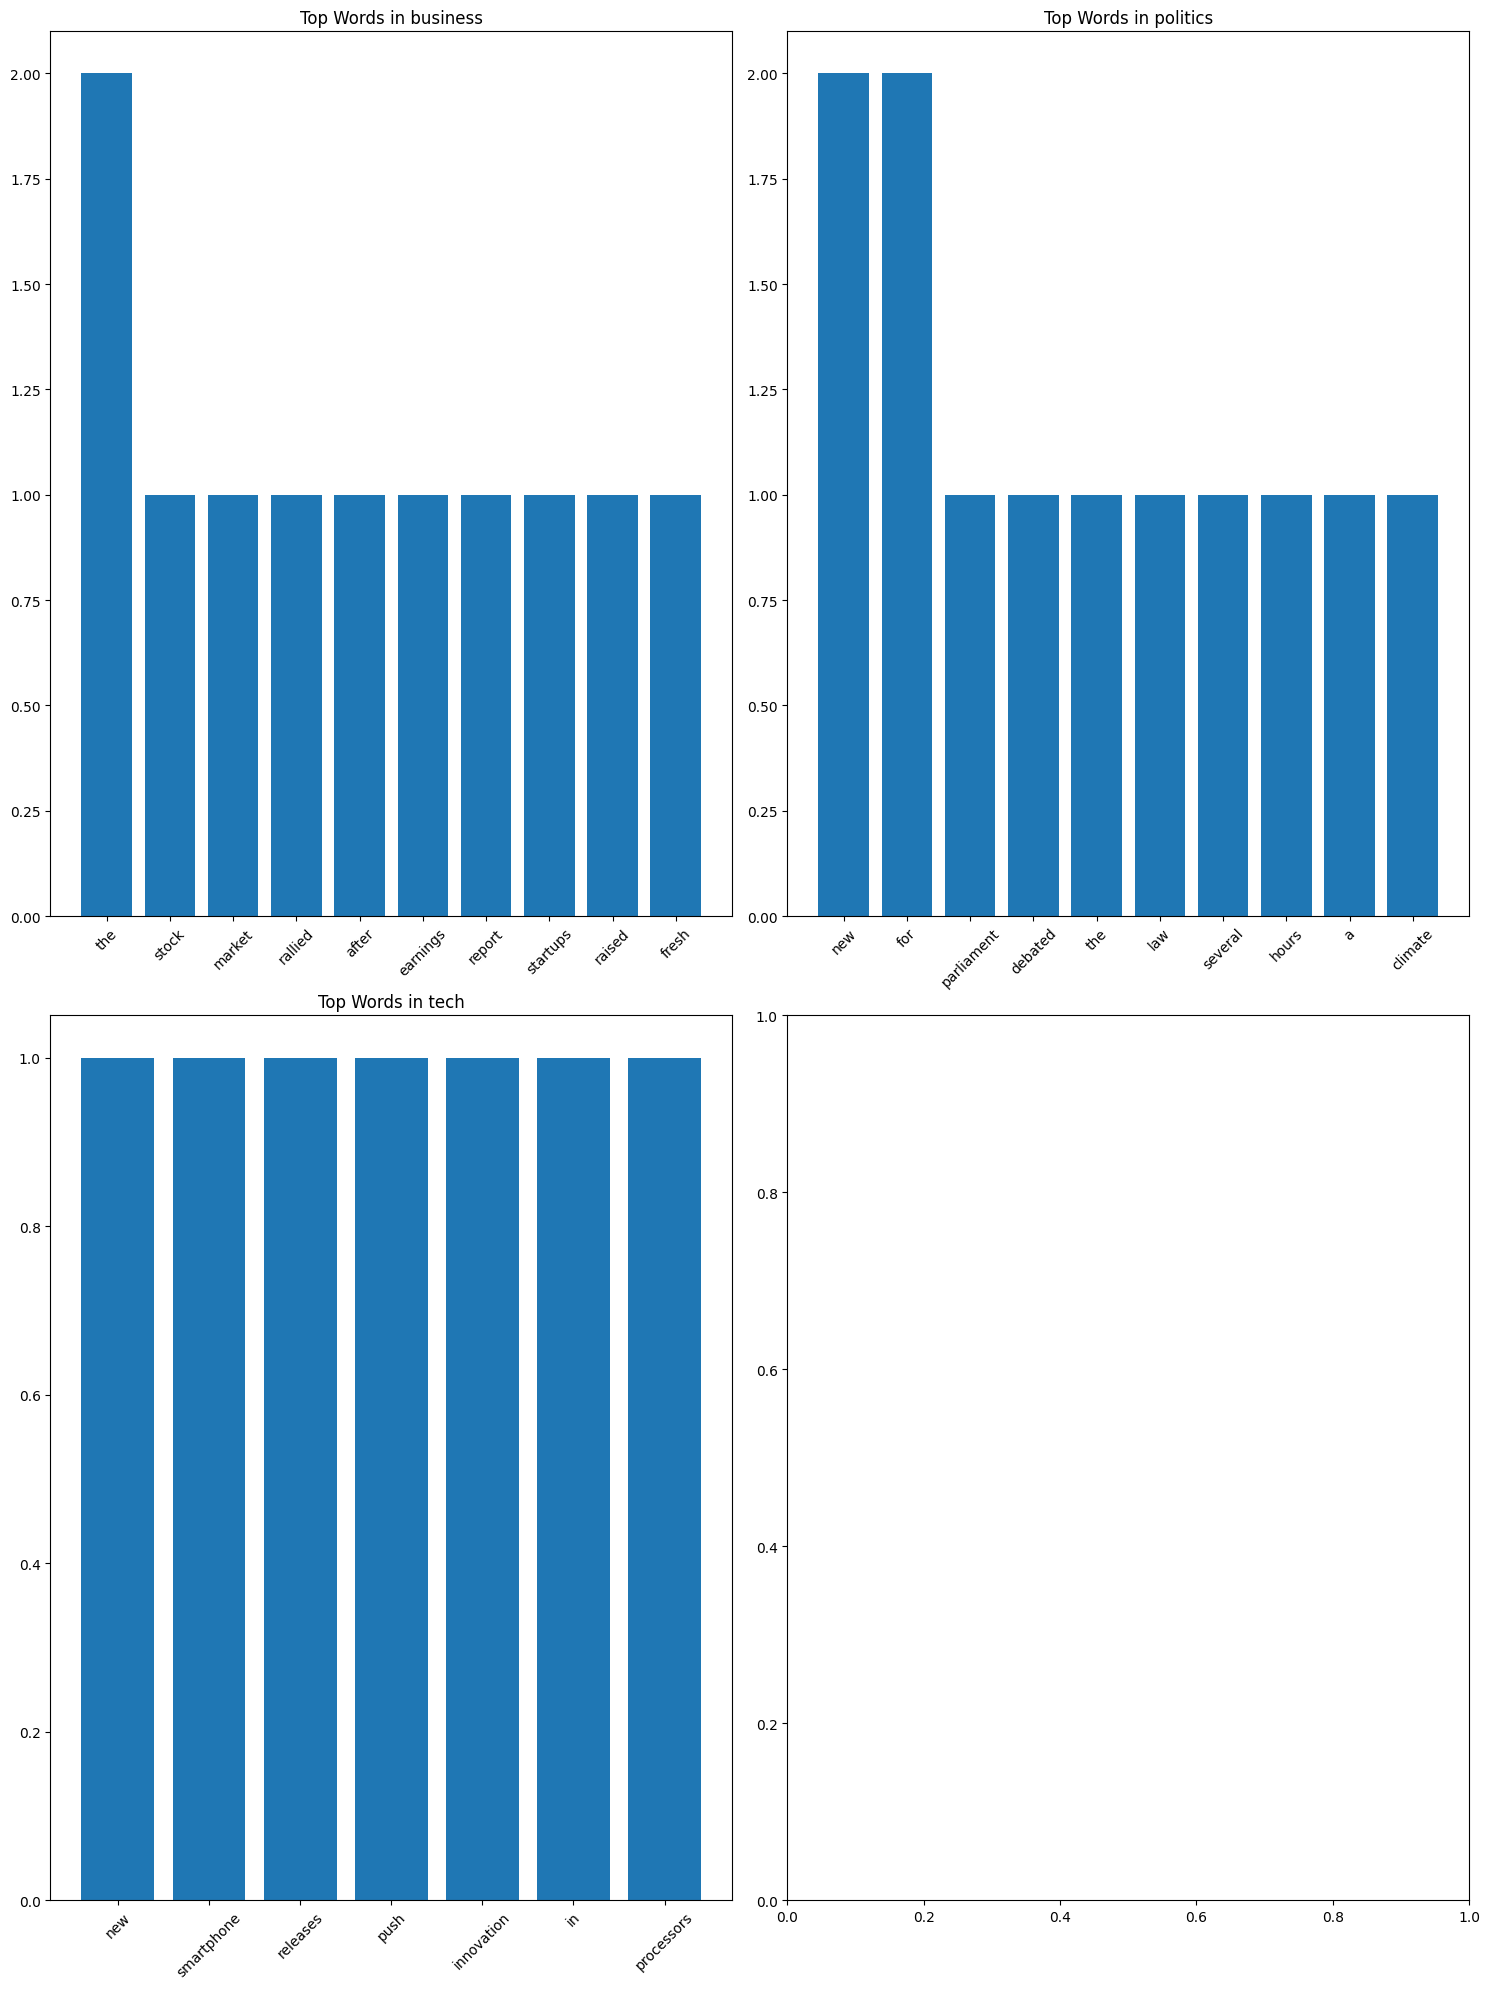

In [35]:
def clean_text(text):
    text = re.sub(r'\W', ' ', str(text).lower())
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\^[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


df['clean_text'] = df['text'].apply(clean_text)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print("Average word count per category:\n",
      df.groupby('category')['word_count'].mean())

# Most common words
all_words = ' '.join(df['clean_text'].dropna()).split()
common_words = Counter(all_words).most_common(20)
print("\nTop 20 common words:\n", common_words[:10])

# Plot top words per category
categories = sorted(df['category'].unique())
n_cats = len(categories)
fig, axes = plt.subplots((n_cats + 1) // 2, 2,
                         figsize=(15, 10 * ((n_cats + 1) // 2)))
if n_cats == 1:
    axes = [axes]
else:
    axes = axes.ravel()
for i, cat in enumerate(categories):
    if i >= len(axes):
        break
    cat_df = df[df['category'] == cat]
    cat_words = ' '.join(cat_df['clean_text'].dropna()).split()
    common_cat = Counter(cat_words).most_common(10)
    axes[i].bar([w for w, _ in common_cat], [c for _, c in common_cat])
    axes[i].set_title(f'Top Words in {cat}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Train-Test Split Preview

In [38]:
# Load labels for reference (create if missing)
labels_path = 'model_artifacts/labels.json'
try:
    with open(labels_path, 'r') as f:
        labels_info = json.load(f)
    print("Available categories:", labels_info['categories'])
except FileNotFoundError:
    labels_info = {'categories': sorted(df['category'].unique())}
    print("Created labels:", labels_info['categories'])

# Check class balance for stratified split
class_counts = y.value_counts()
min_count = class_counts.min()
print(f"\nClass counts: {class_counts.to_dict()}")
print(f"Min samples per class: {min_count}")

# Stratified split only if feasible (≥2 per class)
if min_count >= 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)
    print("Used stratified split.")
else:
    # Fallback: Non-stratified (or augment first)
    print("Min samples too low for stratify—using random split.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    # Optional: Quick augment to enable stratify (uncomment if wanted)
    # from sklearn.utils import resample
    # for cat in y.unique():
    #     if class_counts[cat] < 2:
    #         minority = df[df['category'] == cat]
    #         augmented = resample(minority, n_samples=2, random_state=42)
    #         df = pd.concat([df, augmented])
    # X, y = df['text'], df['category']
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # print("Augmented low-sample classes and used stratified split.")

print("Train set distribution:\n", y_train.value_counts().sort_index())
print("\nTest set distribution:\n", y_test.value_counts().sort_index())

Available categories: ['business', 'entertainment', 'politics', 'sport', 'tech']

Class counts: {'business': 2, 'politics': 2, 'tech': 1}
Min samples per class: 1
Min samples too low for stratify—using random split.
Train set distribution:
 category
business    2
politics    1
tech        1
Name: count, dtype: int64

Test set distribution:
 category
politics    1
Name: count, dtype: int64
